In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

In [3]:
df = pd.read_csv('customer_conversion.csv')

In [ ]:
df

,age,income,web_visits,ad_clicks,time_on_site,converted
0,56,42.952265,11,4,8.199579,1
1,69,69.507312,13,4,7.243761,1
2,46,72.649084,20,0,6.782121,1
3,32,50.516436,6,2,5.538666,0
4,60,44.564561,9,5,3.744304,0
...,...,...,...,...,...,...
9995,55,61.829600,6,4,3.199824,0
9996,51,57.877360,8,5,3.709659,0
9997,57,50.476017,9,1,5.046075,0
9998,64,63.320377,11,3,3.176895,0


In [ ]:
x=df.drop('converted',axis=1)#it will drop the converted and save rest of them in x for train test split

In [ ]:
y=df['converted'] #independent feature

In [9]:
x

,age,income,web_visits,ad_clicks,time_on_site
0,56,42.952265,11,4,8.199579
1,69,69.507312,13,4,7.243761
2,46,72.649084,20,0,6.782121
3,32,50.516436,6,2,5.538666
4,60,44.564561,9,5,3.744304
...,...,...,...,...,...
9995,55,61.829600,6,4,3.199824
9996,51,57.877360,8,5,3.709659
9997,57,50.476017,9,1,5.046075
9998,64,63.320377,11,3,3.176895


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)#train_test_split

In [11]:
x_train

,age,income,web_visits,ad_clicks,time_on_site
4901,46,66.464944,10,2,9.460275
4375,58,38.082584,15,3,3.568451
6698,23,57.388491,5,3,3.998286
9805,66,47.886887,6,3,1.400424
1101,54,67.858270,9,2,5.455615
...,...,...,...,...,...
5734,59,67.473068,7,2,3.761479
5191,49,69.184084,6,2,2.956420
5390,39,99.375146,13,4,5.411508
860,51,60.408343,10,1,1.703692


In [ ]:
#different perematres 
panelty = ['l1','l2','elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solvers= ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
weight =[{0:w ,1:y} for w in [10,20,30,40,55,100,36,45] for y in [10,20,30,40,55,100,36,45]]
random_states =[21,20,40,42,45,50,55,93,100]
parems = dict(penalty=panelty,C=c_values,class_weight=weight,solver=solvers)

In [ ]:
model = LogisticRegression() #logistic
model.fit(x_train,y_train)

LogisticRegression()

In [37]:
y_pred =model.predict(x_test)
print('accuracy score',accuracy_score(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))


accuracy score 0.9992
[[1241    0]
 [   2 1257]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1241
           1       1.00      1.00      1.00      1259

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



In [ ]:
CV = StratifiedKFold(n_splits=5)

In [41]:
Grid = GridSearchCV(estimator=model,param_grid=parems,cv=CV,scoring='accuracy',n_jobs=-1)

In [42]:
Grid.fit(x_train,y_train)

d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
32000 fits failed out of a total of 57600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3200 fits failed with the following error:
Traceback (most recent call last):
  File "d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\test\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.so

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 10, 1: 10}, {0: 10, 1: 20},
                                          {0: 10, 1: 30}, {0: 10, 1: 40},
                                          {0: 10, 1: 55}, {0: 10, 1: 100},
                                          {0: 10, 1: 36}, {0: 10, 1: 45},
                                          {0: 20, 1: 10}, {0: 20, 1: 20},
                                          {0: 20, 1: 30}, {0: 20, 1: 40},
                                          {0: 20, 1: 55}, {0: 20, 1: 100},
                                          {0: 20, 1: 36}, {0: 20, 1: 45},
                                          {0: 30, 1: 10}, {0: 30, 1: 20},
                                          {0: 30, 1: 30}, {0: 30, 1: 40},
                                          {0: 30, 1: 55}, {0: 30, 1: 100},
                                          {0: 30, 1: 36}, {0: 30, 1: 45},
                                          {0: 40, 1: 10}, {0: 40, 1: 20},
                                          {0: 40, 1: 30}, {0: 40, 1: 40},
                                          {0: 40, 1: 55}, {0: 40, 1: 100}, ...],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [60]:
y_pred =Grid.predict(x_test)
print('accuracy score',accuracy_score(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))

accuracy score 1.0
[[1243    0]
 [   0 1257]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1243
           1       1.00      1.00      1.00      1257

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



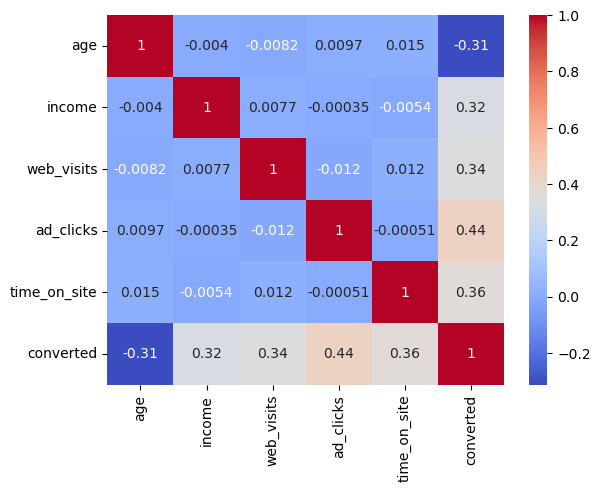

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [63]:
print("Train accuracy:", model.score(x_train, y_train))
print("Test accuracy:", model.score(x_test, y_test))


Train accuracy: 0.9986666666666667
Test accuracy: 0.9992


In [43]:
dummy_prob = [0 for i in range(len(y_test))]

In [45]:
model_prob =model.predict_proba(x_test)

In [46]:
model_prob=model_prob[:,-1]

In [ ]:
dummy_prob_auc = roc_auc_score(y_test,dummy_prob)
model_prob_auc = roc_auc_score(y_test,model_prob)

In [52]:
dummy_fpr,dummy_tpr ,_=roc_curve(y_test,dummy_prob)
model_fpr,model_tpr,Tresholds=roc_curve(y_test,model_prob)

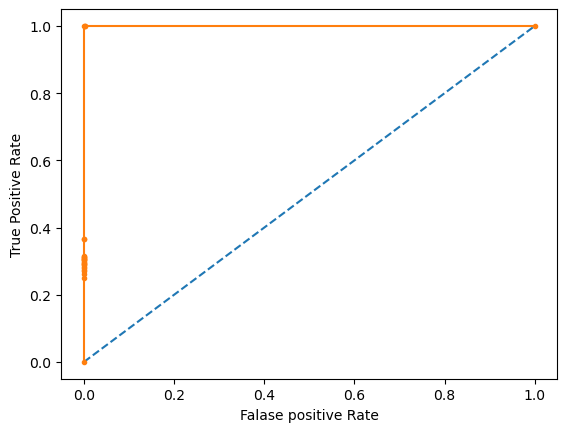

In [54]:
## plot the roc curve for the 
plt.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy_model')
plt.plot(model_fpr,model_tpr,marker='.',label='logistic regression')
plt.xlabel('Falase positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
model = LogisticRegression() #logistic
model.fit(x_train,y_train)

LogisticRegression()